# Simple Lenear Regression

### Loading data and visualizing

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv('E:/Dataset/placement_package.csv')
df.sample(4)

,cgpa,package
156,7.38,3.13
24,6.53,2.71
182,5.88,2.08
130,6.68,2.49


In [9]:
df.shape

(200, 2)

Text(0, 0.5, 'Package(in LPA')

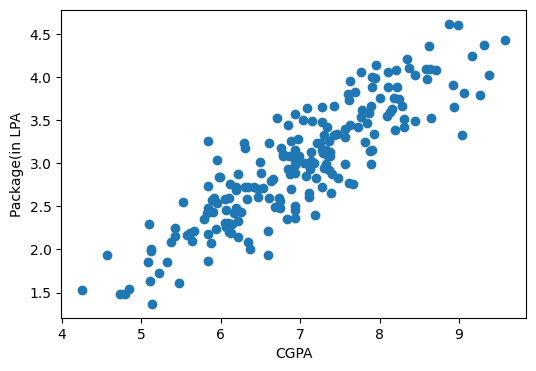

In [71]:
plt.figure(figsize=(6,4))
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA')

### Splitting data and training model

In [72]:
x = df.iloc[:,0:1]
y = df.iloc[:,1]

In [73]:
x.sample(2)

,cgpa
166,8.60
127,6.78


In [74]:
x.shape

(200, 1)

In [75]:
y.shape

(200,)

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3)
x_train.sample()

,cgpa
62,6.34


In [78]:
x_train.shape

(160, 1)

In [40]:
from sklearn.linear_model import LinearRegression

In [79]:
lnr_reg = LinearRegression()

In [96]:
lnr_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Testing the model

In [81]:
x_test.head()

,cgpa
40,9.38
51,9.26
139,7.19
197,7.21
170,6.22


In [82]:
y_test.head()

40     4.02
51     3.79
139    2.40
197    3.24
170    2.87
Name: package, dtype: float64

In [83]:
x_test.iloc[0]

cgpa    9.38
Name: 40, dtype: float64

In [107]:
lnr_reg.predict(x_test.iloc[0].values.reshape(1,1))

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.39751239])

In [108]:
lnr_reg.predict(x_test.iloc[1].values.reshape(1,1))

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.32680345])

### Visualizing the line

In [101]:
m = lnr_reg.coef_
b = lnr_reg.intercept_

print(f'Slope: {m}')
print(f'Y-intercept: {b}')

Slope: [0.5892411]
Y-intercept: -1.1295691481499253


In [109]:
#  y = m*x + b

m*9.26 + b

array([4.32680345])

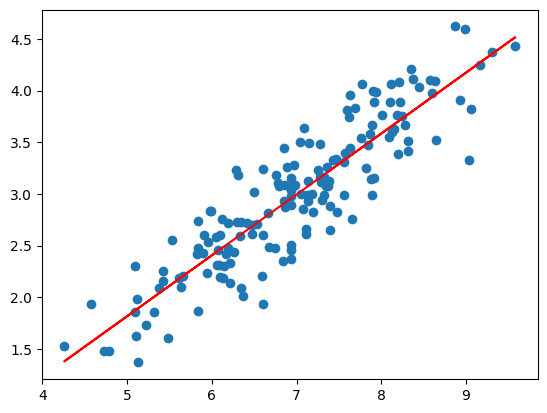

In [93]:
plt.scatter(x_train, y_train)
plt.plot(x_train, lnr_reg.predict(x_train), color='r')

### Checking models score

In [53]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [57]:
print(f'Mean Square errr for train set: {mean_squared_error(lnr_reg.predict(x_train), y_train)}')
print(f'Mean Square errr for test set: {mean_squared_error(lnr_reg.predict(x_test), y_test)}\n')

print(f'Root mean Square errr for train set: {np.sqrt(mean_squared_error(lnr_reg.predict(x_train), y_train))}')
print(f'Root mean Square errr for test set: {np.sqrt(mean_squared_error(lnr_reg.predict(x_test), y_test))}\n')

print(f'Mean absolute errr for train set: {mean_absolute_error(lnr_reg.predict(x_train), y_train)}')
print(f'Mean absolute errr for test set: {mean_absolute_error(lnr_reg.predict(x_test), y_test)}\n')

print(f'r2 Score for train set: {r2_score(lnr_reg.predict(x_train), y_train)}')
print(f'r2 Score for test set: {r2_score(lnr_reg.predict(x_test), y_test)}')

Mean Square errr for train set: 0.09772353638535619
Mean Square errr for test set: 0.14551953158290795

Root mean Square errr for train set: 0.3126076396784893
Root mean Square errr for test set: 0.3814702237172751

Mean absolute errr for train set: 0.24752289520346
Mean absolute errr for test set: 0.310017871705637

r2 Score for train set: 0.7507434498278291
r2 Score for test set: 0.6420716050721467
